**ITESO - Instituto Tecnológico y de Estudios Superiores de Occidente**

---

Alejandro Fernández Vázquez

Andrea Lizeth Arevalo Solis

Arantxa Angulo Flores

# <span style="color:red">Boston Housing Projects - K vecinos cercanos</span>

Modelo de aprendizaje supervisado basado en los k vecinos más cercanos
para predecir el precio de las viviendas (MEDV).

**Entrada:** `data/processed/housing_scaled.csv`

### <span style="color:orange">Bibliotecas</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

### <span style="color:orange">Cargar datos y parámetros</span>

In [2]:
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

df = pd.read_csv('../data/processed/housing_scaled.csv')

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 506, Columnas: 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.670290,0.918420,-1.287909,0,-0.144217,0.475982,-0.120013,0.148015,-0.982843,-0.666608,-1.477181,0.786988,-1.088749,24.0
1,-0.663949,-0.579471,-0.593381,0,-0.740262,0.231390,0.367166,0.572202,-0.867883,-0.987329,-0.309941,0.786988,-0.495302,21.6
2,-0.663955,-0.579471,-0.593381,0,-0.740262,1.444822,-0.265812,0.572202,-0.867883,-0.987329,-0.309941,0.573183,-1.224272,34.7
3,-0.662420,-0.579471,-1.306878,0,-0.835284,1.147817,-0.809889,1.101820,-0.752922,-1.106115,0.110265,0.667741,-1.379766,33.4
4,-0.651339,-0.579471,-1.306878,0,-0.835284,1.384468,-0.511180,1.101820,-0.752922,-1.106115,0.110265,0.786988,-1.038819,36.2


### <span style="color:orange">Separación de características y target</span>

In [3]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=params['modeling']['test_size'],
    random_state=params['modeling']['random_state']
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 404 filas
Test:  102 filas


### <span style="color:orange">Encontrar el mejor k</span>

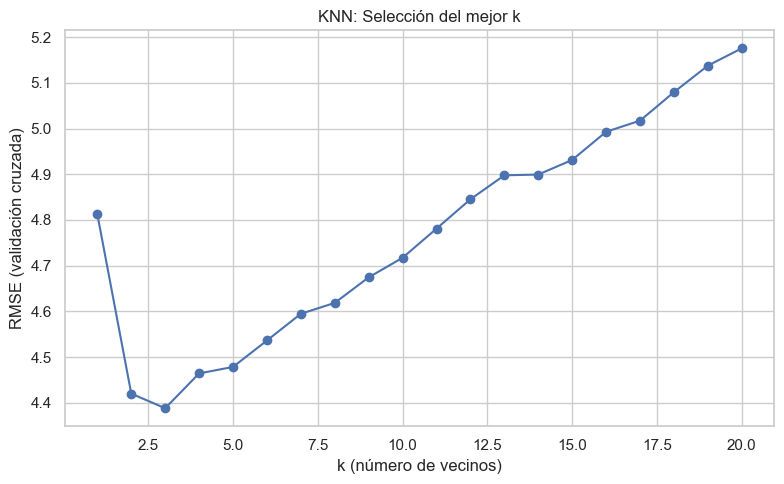

Mejor k: 3


In [4]:
k_range = range(1, 21)
rmse_scores = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    rmse_scores.append(np.sqrt(-scores.mean()))

plt.figure(figsize=(8, 5))
plt.plot(k_range, rmse_scores, 'bo-')
plt.xlabel('k (número de vecinos)')
plt.ylabel('RMSE (validación cruzada)')
plt.title('KNN: Selección del mejor k')
plt.tight_layout()
plt.show()

mejor_k = k_range[np.argmin(rmse_scores)]
print(f"Mejor k: {mejor_k}")

La gráfica muestra el RMSE (error) para cada valor de k usando validación cruzada. La interpretación es simple:

* Eje X — número de vecinos que considera el modelo
* Eje Y — error promedio de predicción (menor es mejor)

### <span style="color:orange">Entrenar modelo con mejor k</span>

In [5]:
knn = KNeighborsRegressor(n_neighbors=mejor_k)
knn.fit(X_train, y_train)

print(f"Modelo KNN entrenado con k={mejor_k}")

Modelo KNN entrenado con k=3


### <span style="color:orange">Evaluar modelo</span>

In [6]:
y_pred = knn.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 4.5164
MAE:  2.6833
R²:   0.7218


### <span style="color:orange">Predicciones vs Valores reales</span>

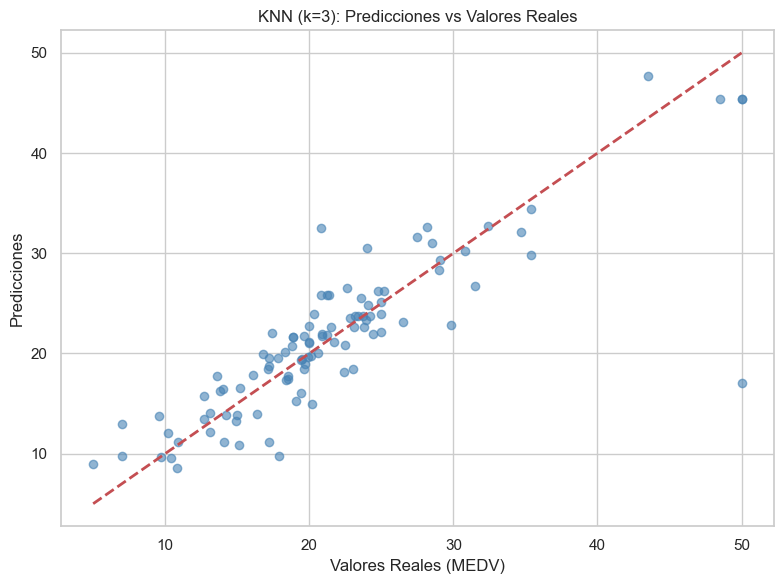

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Valores Reales (MEDV)')
plt.ylabel('Predicciones')
plt.title(f'KNN (k={mejor_k}): Predicciones vs Valores Reales')
plt.tight_layout()
plt.show()

## Conclusiones

**Selección de k:**
Se evaluaron valores de k del 1 al 20 usando validación cruzada con 5 folds.
El valor óptimo fue k=3, que minimiza el RMSE en el conjunto de validación.

**Desempeño del modelo:**
KNN obtuvo un R² de 0.7218, explicando el 72% de la variación en los
precios de las viviendas. El RMSE de 4.52 indica un error promedio
de aproximadamente $4,516 por vivienda.

**Comparación con otros modelos:**
| Modelo          | R²     | RMSE   |
|-----------------|--------|--------|
| Random Forest   | 0.8839 | 2.9175 |
| KNN (k=3)       | 0.7218 | 4.5164 |
| Regresión Lineal| 0.6847 | 4.8082 |

KNN supera a la Regresión Lineal gracias a su capacidad de capturar
relaciones no lineales. Sin embargo, Random Forest sigue siendo el
mejor modelo para este dataset.

**Importancia de la normalización:**
KNN es muy sensible a la escala de las variables. Sin la normalización
aplicada en el cuaderno 03, variables como TAX (rango 524) dominarían
el cálculo de distancias, haciendo el modelo inútil.